In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from RoyalFunctions import compute_msd

Sigma 40, Beta 0.0, Average alpha: 1.04
Sigma 40, Beta 10.0, Average alpha: 1.24
Sigma 40, Beta 20.0, Average alpha: 1.28
Sigma 40, Beta 30.0, Average alpha: 1.73
Sigma 40, Beta 40.0, Average alpha: 1.88
Sigma 40, Beta 50.0, Average alpha: 1.96


/tmp/ipykernel_100506/1794914962.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


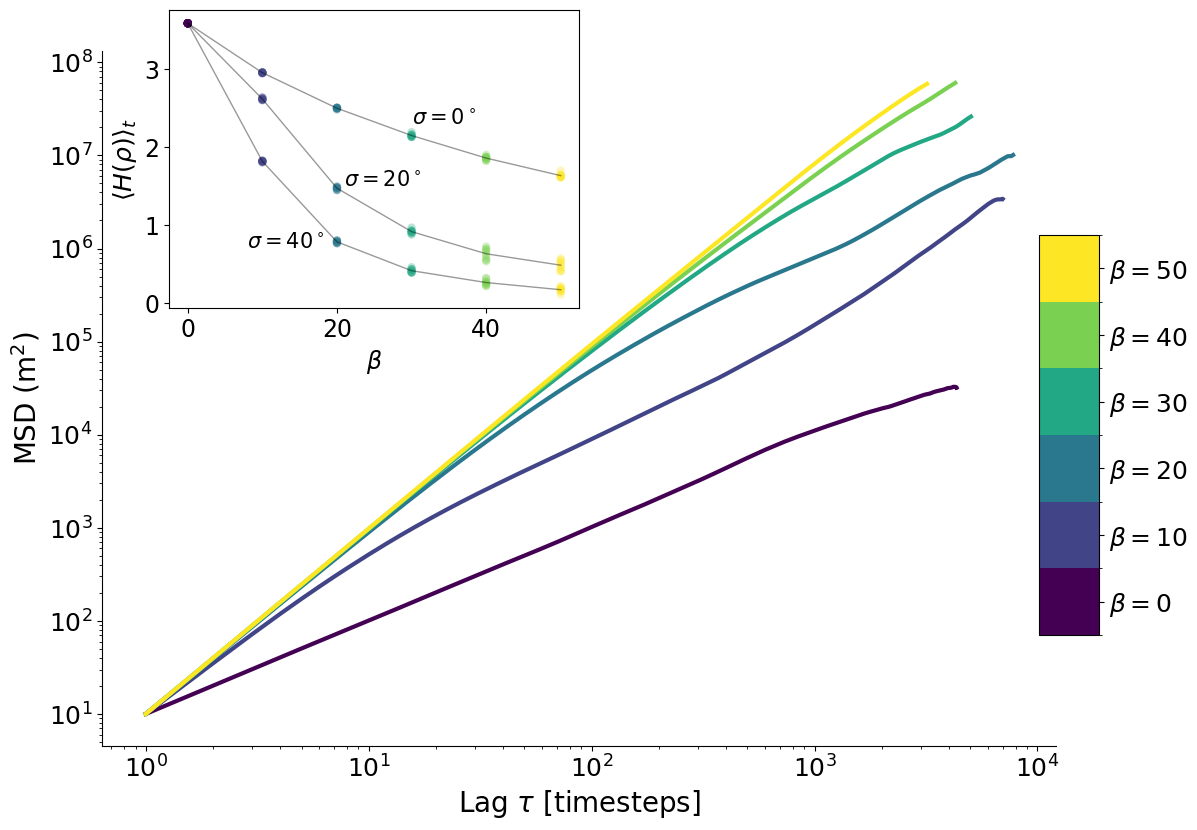

In [2]:
betas = np.linspace(0, 50, 6)
sigmas = [40]
repeats = np.arange(10)
L = 10

# Setup colormap
cmap = cm.viridis
norm = mcolors.BoundaryNorm(boundaries=np.append(betas - np.diff(betas)[0]/2, betas[-1] + np.diff(betas)[0]/2), ncolors=cmap.N)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(figsize=(12, 8))

# === Main plot ===
for sigma in sigmas:
    for idx, beta in enumerate(betas):
        msd_list = []
        lag_list = []
        alpha_list = []

        for repeat in repeats:
            stats = np.load(f'fig04/{beta}_{sigma}_{repeat}_stats.npy')
            angle = np.load(f'fig04/{beta}_{sigma}_{repeat}_angle.npy')
            entropy = np.load(f'fig04/{beta}_{sigma}_{repeat}_entropy.npy')

            n_steps = len(angle)
            posx = np.zeros(n_steps + 1)
            posy = np.zeros(n_steps + 1)
            for t, angle in enumerate(angle):
                posx[t + 1] = posx[t] + L * np.cos(angle)
                posy[t + 1] = posy[t] + L * np.sin(angle)
            pos = np.stack((posx, posy), axis=1)

            msd = compute_msd(pos)
            lags = np.arange(len(msd))
            msd_list.append(msd)
            lag_list.append(lags)

            valid = (lags > 1) & (lags < len(msd) // 5)
            log_lags = np.log10(lags[valid])
            log_msd = np.log10(msd[valid])
            alpha, intercept = np.polyfit(log_lags, log_msd, 1)
            alpha_list.append(alpha)

        min_length = min(len(msd) for msd in msd_list)
        truncated_msds = np.array([msd[:min_length] for msd in msd_list])
        avg_msd = np.mean(truncated_msds, axis=0)
        std_msd = np.std(truncated_msds, axis=0)
        avg_lags = lag_list[0][:min_length]

        valid_avg = (avg_lags > 1) & (avg_lags < len(avg_msd) // 5)
        if np.sum(valid_avg) > 2:
            log_avg_lags = np.log10(avg_lags[valid_avg])
            log_avg_msd = np.log10(avg_msd[valid_avg])
            avg_alpha, avg_intercept = np.polyfit(log_avg_lags, log_avg_msd, 1)
        else:
            avg_alpha = np.nan

        color = cmap(norm(beta))

        ax.plot(avg_lags[1:], avg_msd[1:] / 10, color=color, linewidth=3)

        print(f"Sigma {sigma}, Beta {beta:.1f}, Average alpha: {avg_alpha:.2f}")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r'Lag $\tau$ [timesteps]', fontsize=20)
ax.set_ylabel(r'MSD ($\mathrm{m}^2$)', fontsize=20)
ax.grid(False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=18)

# Add segmented colorbar
colorbar_ax = fig.add_axes([0.87, 0.25, 0.05, 0.5]) 
cbar = fig.colorbar(sm, ticks=betas, cax=colorbar_ax, spacing='proportional', pad=0.02)
cbar.ax.set_yticklabels([fr'$\beta = {b:.0f}$' for b in betas])
cbar.ax.tick_params(labelsize=18)

# === Inset scatter plot (entropy vs beta) ===
# Create inset axes inside the main plot
inset_ax = inset_axes(ax,
                      width="43%",  # relative to parent
                      height="43%",
                      loc='upper left',
                      bbox_to_anchor=(0.07, 0.06, 1, 1),  # x offset only!
                      bbox_transform=ax.transAxes,
                      borderpad=0)

# Now plot entropy scatter plot inside the inset
betas_inset = np.linspace(0, 50, 6)
sigmas_inset = [0, 20, 40]

for sigma in sigmas_inset:
    beta_values = []
    mean_entropies = []
    for beta in betas_inset:
        entropy_list = []
        for repeat in repeats:
            entropy = np.load(f'fig04/{beta}_{sigma}_{repeat}_entropy.npy')
            entropy_list.append(np.mean(entropy))
        
        beta_values.append(beta)
        mean_entropies.append(np.mean(entropy_list))
        # Scatter individual points (keep current style)
        for entropy_value in entropy_list:
            color = cmap(norm(beta)) if beta in betas else 'gray'
            inset_ax.scatter(beta, entropy_value, c=[color], alpha=0.3, edgecolors='none')
    
    # Plot lines connecting the means
    inset_ax.plot(beta_values, mean_entropies, color='k', linewidth=1, label=f'σ = {sigma}', alpha=0.4)   
            # # Use colormap instead of manual colors
            # color = cmap(norm(beta)) if beta in betas else 'gray'  # avoid out-of-range
            # inset_ax.scatter(beta, np.mean(entropy), c=[color], alpha=0.3, edgecolors='none')
inset_ax.text(8, 0.7, r'$\sigma = 40^\circ$', weight='light', fontsize=15)
inset_ax.text(21, 1.5, r'$\sigma = 20^\circ$', weight='light', fontsize=15)
inset_ax.text(30, 2.3, r'$\sigma = 0^\circ$', weight='light', fontsize=15)
inset_ax.tick_params(axis='both', labelsize=17)
inset_ax.set_xlabel(r'$\beta$', fontsize=17)
inset_ax.set_ylabel(r'$\langle H(\rho) \rangle_t$', fontsize=18)
inset_ax.grid(False)

# Optional: make inset axes borders thinner
for spine in inset_ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


/tmp/ipykernel_100506/2764189818.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


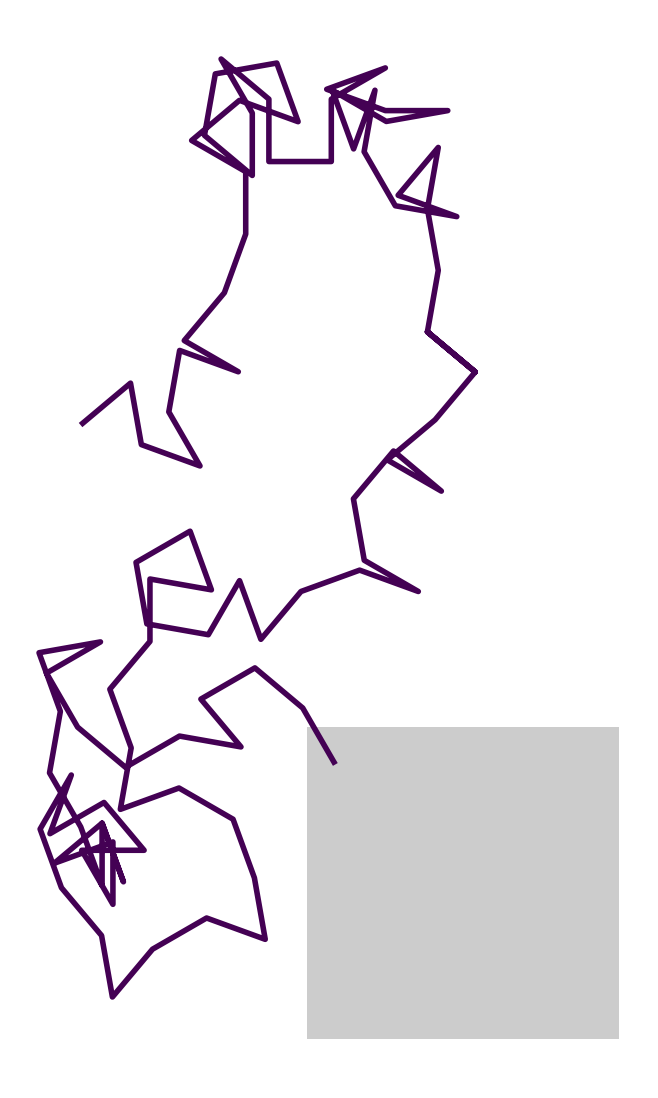

In [3]:
betas = [0.0]
sigmas = [40]
repeats = np.arange(10)
L = 10
# Get the max color from viridis
cmap = cm.get_cmap('viridis')
min_color = cmap(0.0)


stats = np.load(f'fig04/{0.0}_{40}_{8}_stats.npy') #[mean_coherence, num_steps, corr, prominence, lag]
angle = np.load(f'fig04/{0.0}_{40}_{8}_angle.npy')
entropy = np.load(f'fig04/{0.0}_{40}_{8}_entropy.npy')

# Reconstruct position
n_steps = len(angle)
posx = np.zeros(n_steps + 1)
posy = np.zeros(n_steps + 1)

posx[0] = 50*np.random.rand()
posy[0] = 50*np.random.rand()

for t, angle in enumerate(angle):
    posx[t+1] = posx[t] + L * np.cos(angle)
    posy[t+1] = posy[t] + L * np.sin(angle)
pos = np.stack((posx, posy), axis=1)

plt.figure(figsize=(14,14))
#plt.title(f'beta" {beta}, sigma: {sigma}, repeat: {repeat}')
plt.gca().add_patch(plt.Rectangle((0,0), 50, 50, edgecolor=None, facecolor='k', lw=2, alpha=0.2))
plt.plot(posx[:100], posy[:100], zorder=5, lw=4, c=min_color, linestyle='-')
#plt.plot(posx[:100]+0.7, posy[:100], zorder=4, lw=4, c='k', alpha=0.3)
#plt.scatter(posx[:100], posy[:100], zorder=5, c='k', s=5)
plt.gca().set_aspect('equal')
plt.axis('off')
# plt.xlim(-400, 400)
# plt.ylim(-400, 400)
plt.show()

/tmp/ipykernel_100506/1607449962.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


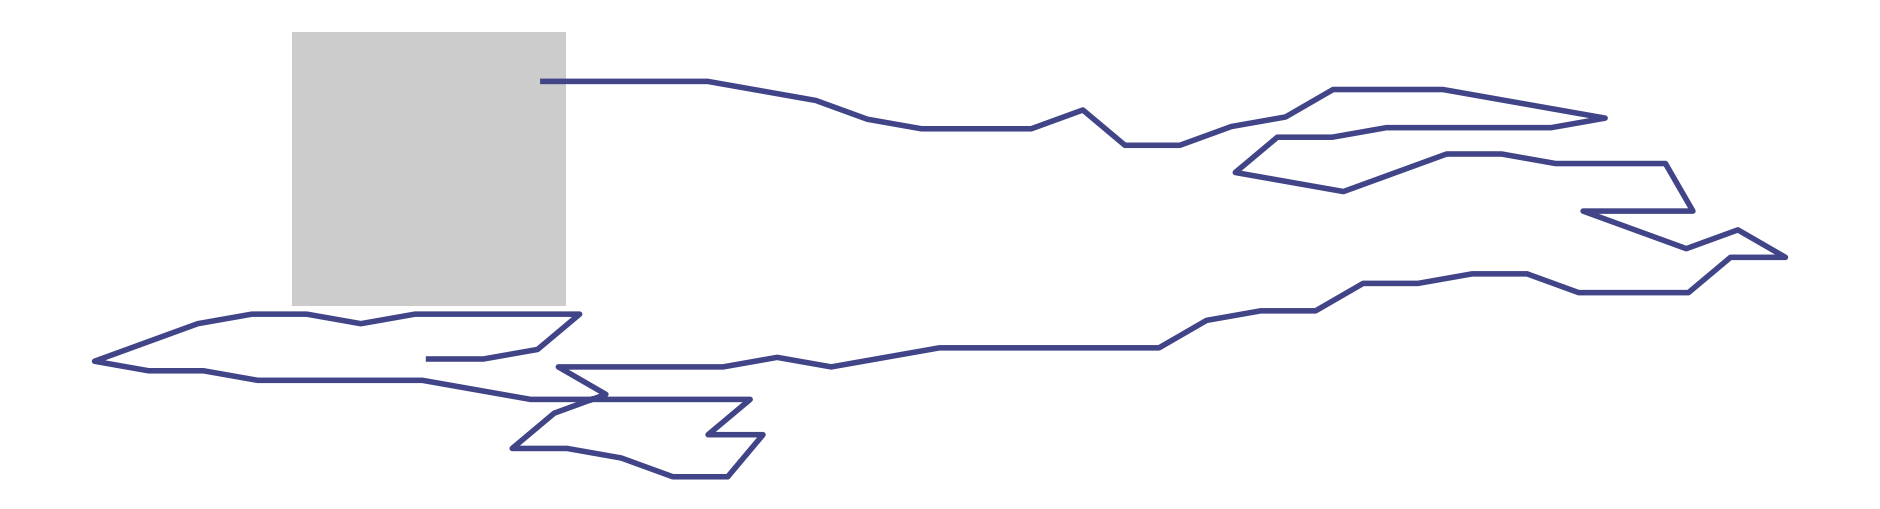

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

L = 10

# Get the max color from viridis
cmap = cm.get_cmap('viridis')
min_color = cmap(0.2)

stats = np.load(f'fig04/{10.0}_{40}_{2}_stats.npy')
angle = np.load(f'fig04/{10.0}_{40}_{2}_angle.npy')
entropy = np.load(f'fig04/{10.0}_{40}_{2}_entropy.npy')

n_steps = len(angle)
posx = np.zeros(n_steps + 1)
posy = np.zeros(n_steps + 1)

posx[0] = 50 * np.random.rand()
posy[0] = 50 * np.random.rand()

for t, angle in enumerate(angle):
    posx[t+1] = posx[t] + L * np.cos(angle)
    posy[t+1] = posy[t] + L * np.sin(angle)

plt.figure(figsize=(24,24))
plt.gca().add_patch(plt.Rectangle((0,0), 50, 50, edgecolor=None, facecolor='k', lw=2, alpha=0.2))
plt.plot(posx[:100], posy[:100], zorder=5, lw=4, c=min_color)  # <<-- Here!
#plt.plot(posx[:100], posy[:100]-2, zorder=4, lw=4, c='k', alpha=0.3)
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()


/tmp/ipykernel_100506/1506056884.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


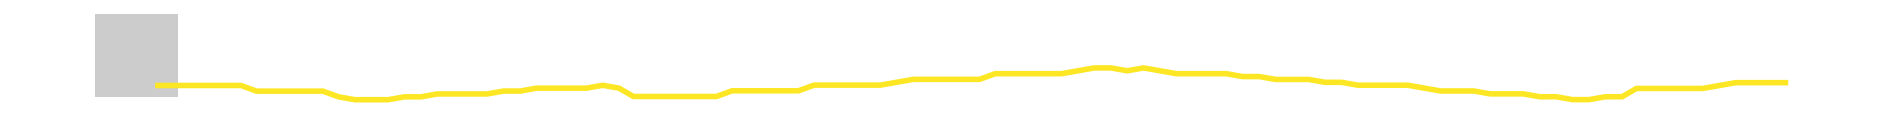

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

L = 10

# Get the max color from viridis
cmap = cm.get_cmap('viridis')
min_color = cmap(1.0)

stats = np.load(f'fig04/{50.0}_{40}_{0}_stats.npy')
angle = np.load(f'fig04/{50.0}_{40}_{0}_angle.npy')
entropy = np.load(f'fig04/{50.0}_{40}_{0}_entropy.npy')

n_steps = len(angle)
posx = np.zeros(n_steps + 1)
posy = np.zeros(n_steps + 1)

posx[0] = 50 * np.random.rand()
posy[0] = 50 * np.random.rand()

for t, angle in enumerate(angle):
    posx[t+1] = posx[t] + L * np.cos(angle)
    posy[t+1] = posy[t] + L * np.sin(angle)

plt.figure(figsize=(24,24))
plt.gca().add_patch(plt.Rectangle((0,0), 50, 50, edgecolor=None, facecolor='k', lw=2, alpha=0.2))
plt.plot(posx[:100], posy[:100], zorder=5, lw=4, c=min_color)  # <<-- Here!
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()
